In [21]:
import numpy as np
import pandas as pb
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Flatten, Input, Dropout
from keras.applications.resnet_v2 import ResNet152V2
from keras.applications.vgg19 import VGG19
import matplotlib.pyplot as plt

In [22]:
resnet_conv = VGG19(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)

In [23]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogsvscats")

print("Path to dataset files:", path)

train_ds = keras.utils.image_dataset_from_directory(
    directory=f'{path}/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224, 224)
)

# Load the validation dataset
validation_ds = keras.utils.image_dataset_from_directory(
    directory=f'{path}/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224, 224)
)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats
Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [24]:
model = Sequential()

model.add(resnet_conv)
model.add(Flatten())
model.add(Dense(256, activation='relu', kernel_initializer='he_uniform', kernel_regularizer=keras.regularizers.l2(0.003)))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu', kernel_initializer='he_uniform', kernel_regularizer=keras.regularizers.l2(0.003)))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 1000)           │   143,667,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       256,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 143,956,521 (549.15 MB)

 Trainable params: 143,956,521 (549.15 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
resnet_conv.trainable = False

In [26]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 1000)           │   143,667,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       256,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 143,956,521 (549.15 MB)

 Trainable params: 289,281 (1.10 MB)

 Non-trainable params: 143,667,240 (548.05 MB)

In [27]:
model.compile(loss='binary_crossentropy', metrics=['accuracy'], optimizer='adam')

In [28]:
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 215s 337ms/step - accuracy: 0.9360 - loss: 0.3889 - val_accuracy: 0.9442 - val_loss: 0.2142
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 206s 330ms/step - accuracy: 0.9477 - loss: 0.2088 - val_accuracy: 0.9446 - val_loss: 0.1975
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 206s 329ms/step - accuracy: 0.9473 - loss: 0.1988 - val_accuracy: 0.9458 - val_loss: 0.1905
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 265s 334ms/step - accuracy: 0.9466 - loss: 0.1923 - val_accuracy: 0.9464 - val_loss: 0.1858
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 206s 329ms/step - accuracy: 0.9484 - loss: 0.1888 - val_accuracy: 0.9466 - val_loss: 0.1816
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 206s 330ms/step - accuracy: 0.9479 - loss: 0.1853 - val_accuracy: 0.9414 - val_loss: 0.1893
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 265s 335ms/step - accuracy: 0.9485 - loss: 0.1808 - val_accuracy: 0.9476 - val_loss: 0.1748
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 208s 333ms/step - accuracy: 0.9492 -

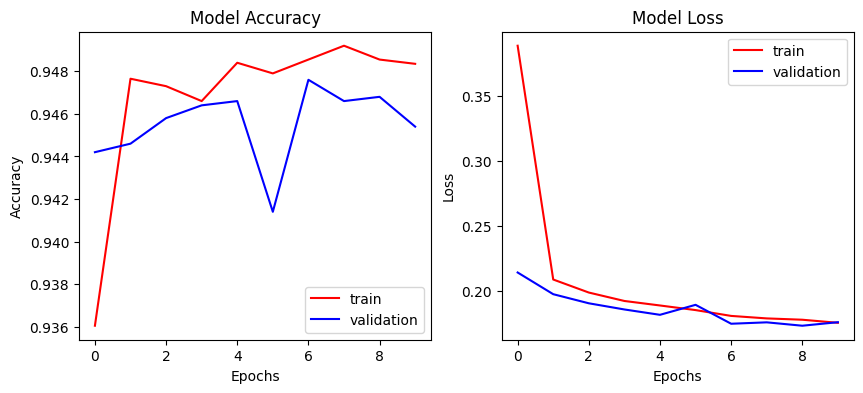

In [29]:
# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

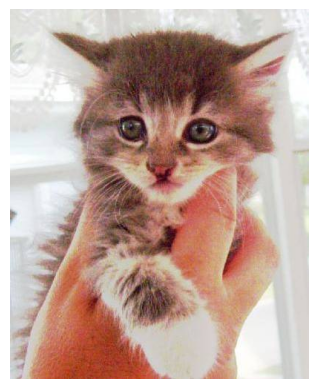

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Raw Prediction Value: 0.5186074376106262
Prediction: It's a DOG!


In [41]:
import cv2
import os

image_path = '/kaggle/input/dogsvscats/train/cats/cat.100.jpg'

if os.path.exists(image_path):
    test_img = cv2.imread(image_path)
    # Convert BGR (OpenCV default) to RGB for correct matplotlib plotting
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.show()

    # Preprocess the image to fit model expectations
    test_img_resized = cv2.resize(test_img, (224, 224))
    test_input = test_img_resized.reshape((1, 224, 224, 3))

    # Scale image pixels if the training pipeline scales them
    test_input = test_input / 255.0

    # Prediction
    prediction = model.predict(test_input)
    print(f"Raw Prediction Value: {prediction[0][0]}")

    if prediction[0][0] < 0.5:
        print("Prediction: It's a CAT!")
    else:
        print("Prediction: It's a DOG!")
else:
    print(f"Image not found at {image_path}. Please check your path.")